Mining for a chaotic system...
Plotting system with parameters: [-0.021 -1.111 -0.078 -0.519  2.326  0.963]


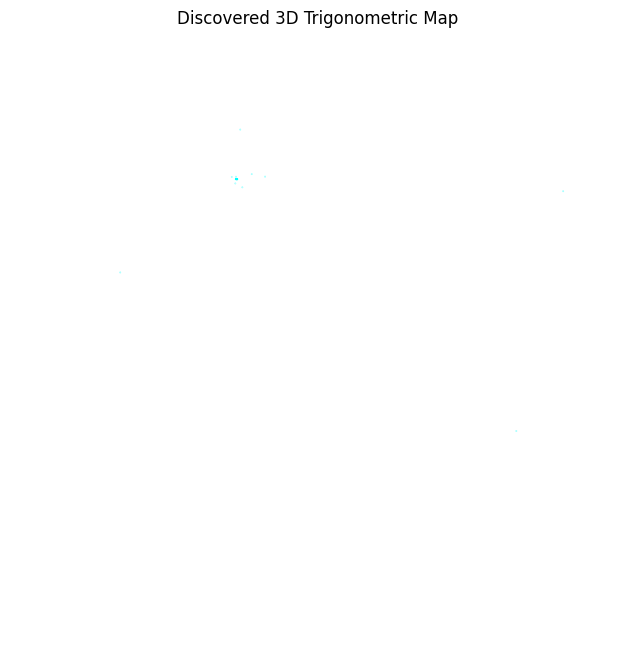

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import random

# @njit compiles the function to machine code
@njit
def generate_3d_map(params, iterations=100000):
    a, b, c, d, e, f = params
    
    # Pre-allocate arrays
    x = np.zeros(iterations)
    y = np.zeros(iterations)
    z = np.zeros(iterations)
    
    # Set starting position
    x[0], y[0], z[0] = 0.1, 0.1, 0.1
    
    # The Iterated Map: Calculate the next point based purely on the last point
    # 3d version of the equation pioneered by Procktor and others in the 80s
    for i in range(1, iterations):
        x[i] = np.sin(a * y[i-1]) + c * np.cos(a * x[i-1]) + np.sin(e * z[i-1])
        y[i] = np.sin(b * x[i-1]) + d * np.cos(b * y[i-1]) + np.cos(f * z[i-1])
        z[i] = np.sin(c * x[i-1]) + e * np.cos(d * y[i-1]) + np.sin(a * z[i-1])
        
    return x, y, z

def mine_for_chaos():
    print("Mining for a chaotic system...")
    
    # Generate 6 random parameters between -2.5 and 2.5
    params = [random.uniform(-2.5, 2.5) for _ in range(6)]
    
    # Run the compiled math for 100,000 steps
    x, y, z = generate_3d_map(tuple(params))
    
    return x, y, z, params

# Run the miner
x, y, z, found_params = mine_for_chaos()

# Plot the results
print(f"Plotting system with parameters: {np.round(found_params, 3)}")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

#create a scatter plot of small transparent points to visualize the chaotic attractor
ax.scatter(x, y, z, s=0.1, alpha=0.5, color='cyan')

ax.set_title("Discovered 3D Trigonometric Map")
# Turn off the axis grid and labels for a cleaner look
ax.axis('off') 

plt.show()

In [24]:
#test that numba is working by running a simple function that creates an array of 42s
import numpy as np
from numba import njit

@njit
def test_numba(n):
    return np.ones(n) * 42

print(f"Success! Numba is working. Result: {test_numba(5)}")

Success! Numba is working. Result: [42. 42. 42. 42. 42.]


In [25]:
# 1. Run the miner to find random parameters
x, y, z, found_params = mine_for_chaos()

# 2. Look at the first 5 numbers of the X sequence
print("First 5 points of X sequence:")
print(x[:5])

# 3. Check how many unique points are in the X sequence
if np.unique(x).size > 1000:
    print("\nRESULT: This looks like a complex system!")
else:
    print("\nRESULT: This system collapsed or is a simple loop.")

Mining for a chaotic system...
First 5 points of X sequence:
[0.1        0.41454077 0.46035379 0.9697809  0.44201651]

RESULT: This looks like a complex system!


In [26]:
import numpy as np
from numba import njit
import random

#Calculates the Lyapunov Exponent to measure how chaotic a system is.
#positive LLE means chaos, negative means stable, zero means borderline
@njit
def calculate_lyapunov(params, iterations=10000):
    a, b, c, d, e, f = params
    
    # Start the main point
    x, y, z = 0.1, 0.1, 0.1
    
    # Start the shadow point slightly offset from the main point
    d0 = 1e-8
    xs, ys, zs = x + d0, y, z
    
    lyapunov_sum = 0.0
    
    # Let the system run for 1000 steps without measuring 
    # this period allows th points to shift from the intial random starting point to the actual 
    # attractor shape, which gives us a more accurate LLE measurement
    for _ in range(1000):
        x_new = np.sin(a * y) + c * np.cos(a * x) + np.sin(e * z)
        y_new = np.sin(b * x) + d * np.cos(b * y) + np.cos(f * z)
        z_new = np.sin(c * x) + e * np.cos(d * y) + np.sin(a * z)
        x, y, z = x_new, y_new, z_new
        
    # Reset shadow point to be exactly d0 away after the intial "settling" period 
    # This ensures we are measuring the divergence from the attractor, not just from the random starting point
    xs, ys, zs = x + d0, y, z 
    
    # RUN & MEASURE
    for _ in range(iterations):
        # Step main point forward
        x_next = np.sin(a * y) + c * np.cos(a * x) + np.sin(e * z)
        y_next = np.sin(b * x) + d * np.cos(b * y) + np.cos(f * z)
        z_next = np.sin(c * x) + e * np.cos(d * y) + np.sin(a * z)
        
        # Step shadow point forward
        xs_next = np.sin(a * ys) + c * np.cos(a * xs) + np.sin(e * zs)
        ys_next = np.sin(b * xs) + d * np.cos(b * ys) + np.cos(f * zs)
        zs_next = np.sin(c * xs) + e * np.cos(d * ys) + np.sin(a * zs)
        
        # Calculate new distance between them (d1)
        dx = xs_next - x_next
        dy = ys_next - y_next
        dz = zs_next - z_next
        d1 = np.sqrt(dx**2 + dy**2 + dz**2)
        
        # if they perfectly collide, prevent a divide-by-zero math error
        if d1 == 0:
            d1 = 1e-16
            
        # Add the exponential growth to our running score
        lyapunov_sum += np.log(d1 / d0)
        
        # RENORMALIZE: Pull the shadow point back so it is exactly d0 away again
        xs = x_next + (dx / d1) * d0
        ys = y_next + (dy / d1) * d0
        zs = z_next + (dz / d1) * d0
        
        # Update main points for the next loop
        x, y, z = x_next, y_next, z_next
        
    # Return the average growth per step (The Lyapunov Exponent)
    return lyapunov_sum / iterations


# The Automated Miner: Loops forever until it finds a cryptographic key
def find_encryption_key():
    print("Starting automated chaos miner...")
    attempts = 0
    
    while True:
        attempts += 1
        # Pick random parameters for the system
        params = [random.uniform(-2.5, 2.5) for _ in range(6)]
        
        # Evaluate them by calculating the Lyapunov Exponent
        lle = calculate_lyapunov(tuple(params))
        
        # If LLE is > 0.1, we have a strong chaotic system that could be used for encryption
        if lle > 0.1:
            print(f"\nJACKPOT Found a strong chaotic system after {attempts} attempts.")
            print(f"Lyapunov Exponent: {lle:.4f}")
            print(f"Secret Encryption Key (Parameters): {np.round(params, 4)}")
            return params
        
        # Optional: Print progress every 100 attempts so you know it's working
        if attempts % 100 == 0:
            print(f"Searched {attempts} systems... no strong chaos yet.")

# Run the automated miner!
secret_key = find_encryption_key()

Starting automated chaos miner...

JACKPOT Found a strong chaotic system after 4 attempts.
Lyapunov Exponent: 0.4843
Secret Encryption Key (Parameters): [-0.9337  1.9633 -0.6446  1.4323  0.4711  1.2809]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def encrypt_image(image_path, secret_key):
    print("Loading image...")
    # Load the image and convert to standard 8-bit integers (0-255)
    img = plt.imread(image_path)
    if img.dtype == np.float32:
        img = (img * 255).astype(np.uint8)
        
    # Get the dimensions: Height, Width, Color Channels (RGB)
    h, w, channels = img.shape
    total_values = h * w * channels
    
    print(f"Image size: {h}x{w}. Generating {total_values} chaotic numbers...")
    
    # Run the map for the exact number of pixels in the image (times 3 for RGB channels)
    x, y, z = generate_3d_map(secret_key, iterations=total_values)
    
    # Flatten the 3D image matrix into a 1D list of values
    flat_img = img.flatten()
    
    print("Applying Confusion (Shuffling)...")
    # np.argsort looks at the chaotic X array and returns the indices that would sort it.
    # uses this list of indices that would sort the chaotic X values, which is effectively a random shuffle
    shuffle_indices = np.argsort(x)
    scrambled_img = flat_img[shuffle_indices]
    
    print("Applying Diffusion (Color XORing)...")
    # Take the Y coordinates, multiply to extract the random decimal noise, 
    # and convert to numbers between 0 and 255
    y_integers = ((np.abs(y) * 1000000).astype(np.int64) % 256).astype(np.uint8)
    
    # The magical XOR operation. This destroys the color data securely.
    encrypted_flat = scrambled_img ^ y_integers
    
    # Fold the 1D list back into the original 2D image shape
    encrypted_img = encrypted_flat.reshape(h, w, channels)
    
    # Display the results side by side
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img)
    ax[0].set_title("Original Image")
    ax[0].axis('off')
    
    ax[1].imshow(encrypted_img)
    ax[1].set_title("Encrypted Ciphertext")
    ax[1].axis('off')
    
    plt.show()
    
    return encrypted_img, shuffle_indices, y_integers

# --- To run this, you just need to pass it an image and your key! ---
# my_encrypted_image, indices, y_key = encrypt_image("my_picture.jpg", secret_key)

Loading image...
Image size: 1306x863. Generating 4508312 chaotic numbers...
Applying Confusion (Shuffling)...
Applying Diffusion (Color XORing)...


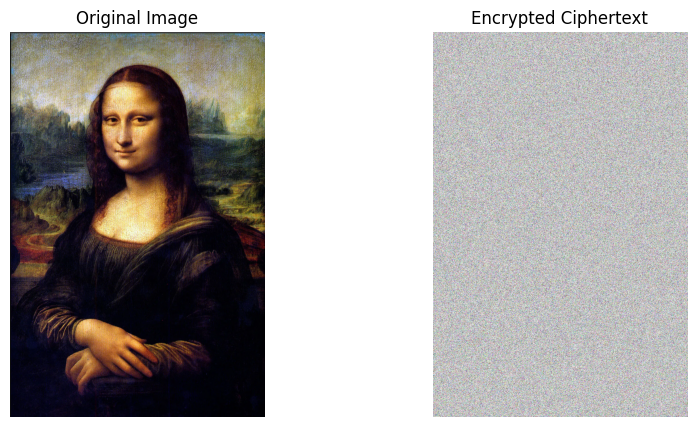


Encryption complete! Your image is now mathematically locked.


In [28]:
# test with test image and key mined previously
encrypted_image, shuffle_indices, y_key = encrypt_image('test-image.png', secret_key)

print("\nEncryption complete! Your image is now mathematically locked.")